# Q2
McKenna Adams

In [67]:
import pandas as pd
import seaborn as sns

In [ ]:
ads = pd.read_csv("FacebookAdLibraryReport_2026-03-14_US_lifelong_advertisers.csv")
locs = pd.read_csv("FacebookAdLibraryReport_2026-03-14_US_lifelong_locations.csv")
census = pd.read_csv("CensusData.csv")
df_pop = pd.read_csv("Population.csv")

ads.head()

/var/folders/9t/q_tp5x216p58xd59ftp35fsr0000gn/T/ipykernel_54479/2189976358.py:1: DtypeWarning: Columns (0: Amount spent (USD)) have mixed types. Specify dtype option on import or set low_memory=False.
  ads = pd.read_csv("FacebookAdLibraryReport_2026-03-14_US_lifelong_advertisers.csv")


,Page ID,Page name,Disclaimer,Amount spent (USD),Number of ads in Library
0,7860876103,Joe Biden,BIDEN VICTORY FUND,79741106,72551
1,6756153498,Mike Bloomberg,Mike Bloomberg 2020 Inc,63326609,181199
2,153080620724,Donald J. Trump,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,58272160,312233
3,7860876103,Joe Biden,BIDEN FOR PRESIDENT,53021585,54401
4,24413227922,Kamala Harris,HARRIS FOR PRESIDENT,45387840,49107


In [69]:
locs.head()

,Location name,Amount spent (USD)
0,Alabama,52314895
1,Alaska,19731604
2,American Samoa,15092
3,Arizona,196426817
4,Arkansas,34139655


In [70]:
print(census)
census.head()

                              Label (Grouping) Alabama!!Households!!Estimate  \
0                                        Total                     2,059,528   
1                            Less than $10,000                          6.4%   
2                           $10,000 to $14,999                          4.7%   
3                           $15,000 to $24,999                          7.8%   
4                           $25,000 to $34,999                          7.9%   
5                           $35,000 to $49,999                         11.2%   
6                           $50,000 to $74,999                         16.8%   
7                           $75,000 to $99,999                         13.3%   
8                         $100,000 to $149,999                         16.0%   
9                         $150,000 to $199,999                          7.5%   
10                            $200,000 or more                          8.3%   
11                     Median income (do

,Label (Grouping),Alabama!!Households!!Estimate,Alabama!!Households!!Margin of Error,Alabama!!Families!!Estimate,Alabama!!Families!!Margin of Error,Alabama!!Married-couple families!!Estimate,Alabama!!Married-couple families!!Margin of Error,Alabama!!Nonfamily households!!Estimate,Alabama!!Nonfamily households!!Margin of Error,Alaska!!Households!!Estimate,...,Wyoming!!Nonfamily households!!Estimate,Wyoming!!Nonfamily households!!Margin of Error,Puerto Rico!!Households!!Estimate,Puerto Rico!!Households!!Margin of Error,Puerto Rico!!Families!!Estimate,Puerto Rico!!Families!!Margin of Error,Puerto Rico!!Married-couple families!!Estimate,Puerto Rico!!Married-couple families!!Margin of Error,Puerto Rico!!Nonfamily households!!Estimate,Puerto Rico!!Nonfamily households!!Margin of Error
0,Total,"2,059,528","±11,700","1,328,397","±15,669","945,230","±13,945","731,131","±12,070","274,045",...,"96,166","±4,034","1,242,609","±10,856","764,486","±11,451","419,876","±8,970","478,123","±10,310"
1,"Less than $10,000",6.4%,±0.3,3.7%,±0.3,1.3%,±0.2,12.2%,±0.8,3.7%,...,10.1%,±1.9,18.3%,±0.6,12.3%,±0.7,5.2%,±0.6,29.5%,±1.1
2,"$10,000 to $14,999",4.7%,±0.3,2.2%,±0.2,0.9%,±0.1,9.5%,±0.6,2.0%,...,4.8%,±1.2,11.0%,±0.5,7.7%,±0.5,6.2%,±0.7,17.0%,±0.9
3,"$15,000 to $24,999",7.8%,±0.3,5.1%,±0.4,2.5%,±0.3,13.3%,±0.7,5.2%,...,12.0%,±1.9,17.9%,±0.6,17.1%,±0.8,14.3%,±0.8,20.4%,±1.0
4,"$25,000 to $34,999",7.9%,±0.3,5.8%,±0.4,4.0%,±0.3,11.9%,±0.7,4.9%,...,12.3%,±1.9,12.1%,±0.6,13.1%,±0.6,12.9%,±0.8,10.5%,±1.0


In [71]:
df_pop.head()

,Label (Grouping),Alabama!!Total population!!Estimate,Alabama!!Total population!!Margin of Error,Alaska!!Total population!!Estimate,Alaska!!Total population!!Margin of Error,Arizona!!Total population!!Estimate,Arizona!!Total population!!Margin of Error,Arkansas!!Total population!!Estimate,Arkansas!!Total population!!Margin of Error,California!!Total population!!Estimate,...,Washington!!Total population!!Estimate,Washington!!Total population!!Margin of Error,West Virginia!!Total population!!Estimate,West Virginia!!Total population!!Margin of Error,Wisconsin!!Total population!!Estimate,Wisconsin!!Total population!!Margin of Error,Wyoming!!Total population!!Estimate,Wyoming!!Total population!!Margin of Error,Puerto Rico!!Total population!!Estimate,Puerto Rico!!Total population!!Margin of Error
0,Total,"4,997,675",*****,"735,951",*****,"7,079,203",*****,"3,006,309",*****,"39,455,353",...,"7,617,364",*****,"1,801,049",*****,"5,871,661",*****,"576,641",*****,"3,311,274",*****


In [ ]:
pop_cols = [col for col in df_pop.columns if "Estimate" in col]

pop_wide = df_pop[pop_cols]

pop_wide = pop_wide.iloc[0]

pop = pop_wide.reset_index()
pop.columns = ["state_raw", "population"]

pop["state"] = pop["state_raw"].str.split("!!").str[0]

pop["population"] = (
    pop["population"]
    .str.replace(",", "", regex=False)
    .astype(int)
)
pop = pop[["state", "population"]]

print(pop)
pop.head()

                   state  population
0                Alabama     4997675
1                 Alaska      735951
2                Arizona     7079203
3               Arkansas     3006309
4             California    39455353
5               Colorado     5723176
6            Connecticut     3605330
7               Delaware      981892
8   District of Columbia      683154
9                Florida    21339762
10               Georgia    10625615
11                Hawaii     1453498
12                 Idaho     1811617
13              Illinois    12821813
14               Indiana     6751340
15                  Iowa     3179090
16                Kansas     2932099
17              Kentucky     4494141
18             Louisiana     4657305
19                 Maine     1357046
20              Maryland     6148545
21         Massachusetts     6991852
22              Michigan    10062512
23             Minnesota     5670472
24           Mississippi     2967023
25              Missouri     6141534
2

,state,population
0,Alabama,4997675
1,Alaska,735951
2,Arizona,7079203
3,Arkansas,3006309
4,California,39455353


In [73]:
median_row = census[census["Label (Grouping)"] == "Median income (dollars)"]
estimate_cols = [col for col in census.columns if "Estimate" in col]
median_est = median_row[estimate_cols]

median_long = median_est.melt(
    var_name="state_raw",
    value_name="median_income"
)
median_long["state"] = median_long["state_raw"].str.split("!!").str[0]
median_long["median_income"] = (
    median_long["median_income"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

median_long["median_income"] = pd.to_numeric(median_long["median_income"], errors="coerce")
median_final = median_long[["state", "median_income"]]


In [76]:
amt_spent_with_population = pop.merge(locs,left_on="state", right_on="Location name", how="inner")
amt_spent_with_population = amt_spent_with_population[["state", "population", "Amount spent (USD)"]]
amt_spent_with_population.head()
print((amt_spent_with_population))

amt_spent_with_population_long = amt_spent_with_population.melt(
    id_vars="state",
    value_vars=["population", "Amount spent (USD)"],
    var_name="metric",
    value_name="value"
)


df = amt_spent_with_population.merge(
    median_final,
    on="state",
    how="inner"
)

df["ad_per_capita"] = df["Amount spent (USD)"] / df["population"]

df_sorted = df.sort_values(by="ad_per_capita", ascending=False)

df_sorted.head()

             state  population  Amount spent (USD)
0          Alabama     4997675            52314895
1           Alaska      735951            19731604
2          Arizona     7079203           196426817
3         Arkansas     3006309            34139655
4       California    39455353           576650760
5         Colorado     5723176           105240305
6      Connecticut     3605330            47075808
7         Delaware      981892            14517354
8          Florida    21339762           360003230
9          Georgia    10625615           212183721
10          Hawaii     1453498            15026030
11           Idaho     1811617            22642182
12        Illinois    12821813           174217685
13         Indiana     6751340            75740500
14            Iowa     3179090            62968369
15          Kansas     2932099            38275874
16        Kentucky     4494141            57692606
17       Louisiana     4657305            59499826
18           Maine     1357046 

,state,population,Amount spent (USD),median_income,ad_per_capita
103,Montana,1077978,33767390,44974,31.324749
102,Montana,1077978,33767390,108127,31.324749
101,Montana,1077978,33767390,97801,31.324749
100,Montana,1077978,33767390,75340,31.324749
75,Maine,1357046,40171918,45568,29.602473


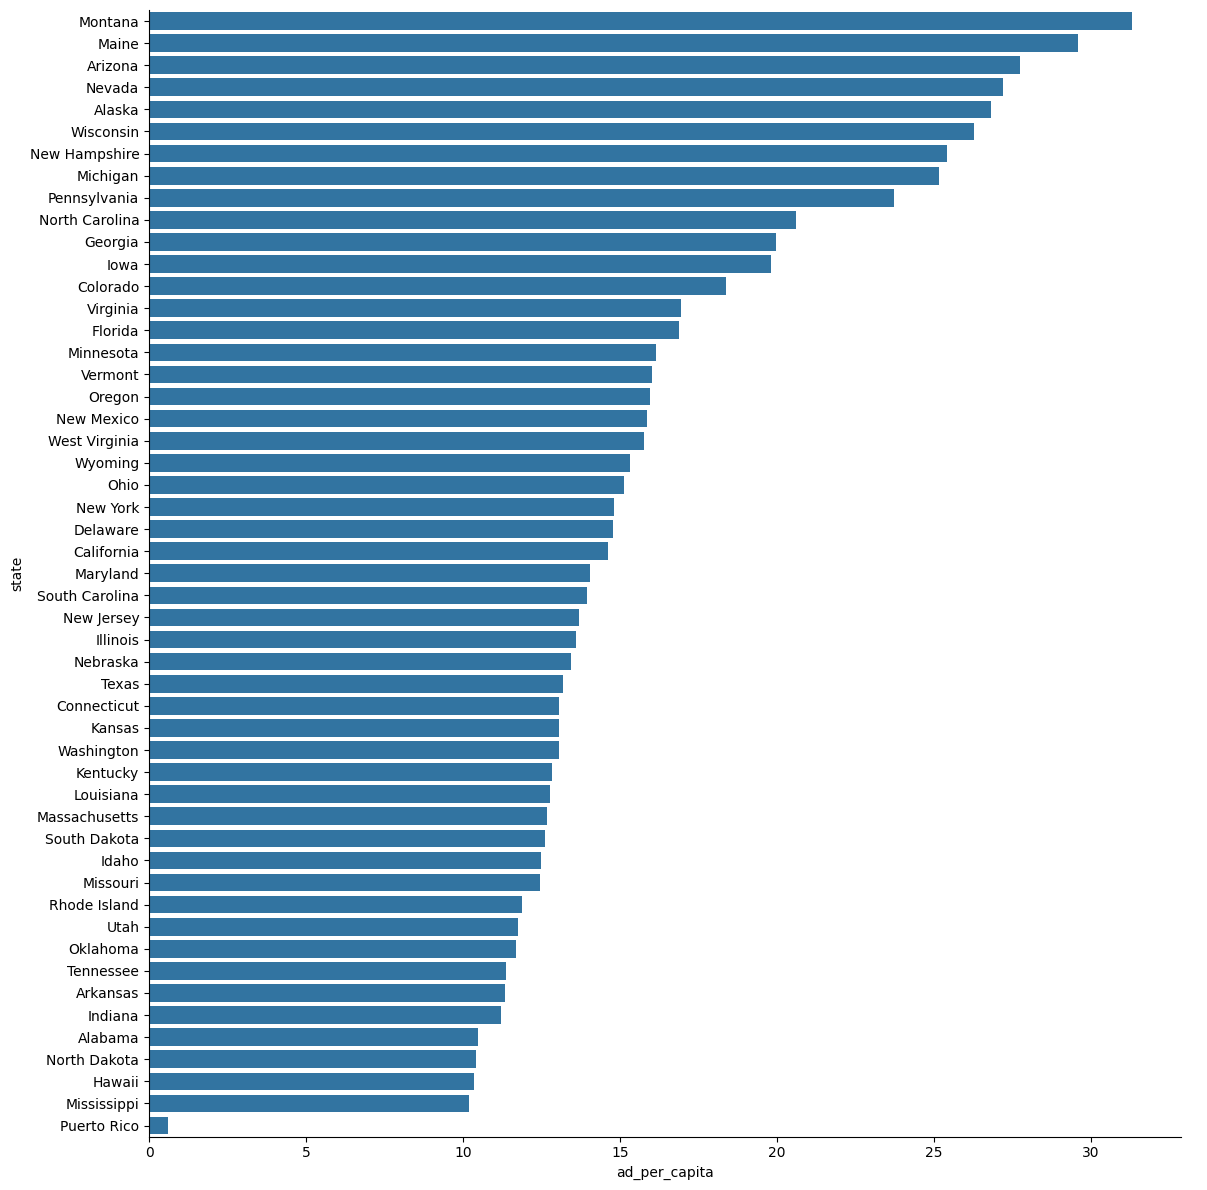

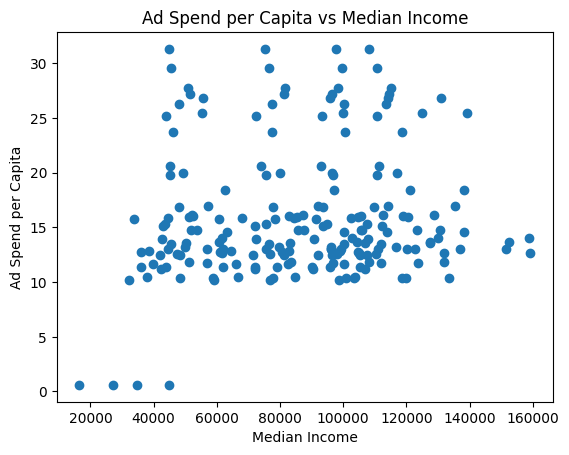

In [ ]:
sns.catplot(
    data=df_sorted,
    y="state",
    x="ad_per_capita",
    kind="bar",
    height=12,
    aspect=1
)
